📊 DATASET
    Study_Hours  Attendance  Result
0             1          90       1
1             2          85       1
2             3          80       1
3             4          75       0
4             5          70       0
5             6          65       0
6             7          60       1
7             8          55       1
8             2          55       0
9             3          60       0
10            6          85       1
11            7          90       1

⚡ NON-LINEAR SVM TRAINED SUCCESSFULLY!

🎯 PREDICTIONS
[1 0 1]

✅ ACTUAL VALUES
[1 0 1]

📈 ACCURACY: 1.0

🔲 CONFUSION MATRIX
[[1 0]
 [0 2]]

👨‍🎓 NEW STUDENT
   Study_Hours  Attendance
0            5          72
Prediction: FAIL ❌


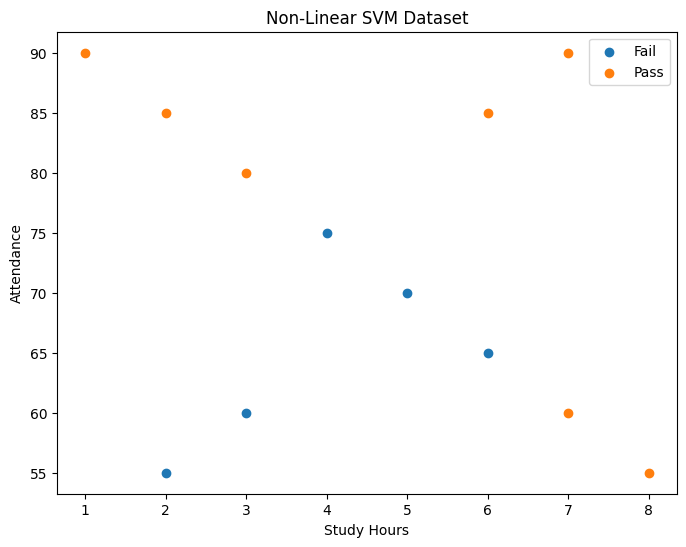

In [1]:
# =====================================================
# ⚡ Day 20 - Non-Linear SVM using RBF Kernel
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Create Non-Linear Dataset
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 2, 3, 6, 7],
    "Attendance": [90, 85, 80, 75, 70, 65, 60, 55, 55, 60, 85, 90],
    "Result": [1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1]
}

df = pd.DataFrame(data)

print("📊 DATASET")
print(df)

# 2. Features and Target
X = df[["Study_Hours", "Attendance"]]
y = df["Result"]

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# 4. Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Create Non-Linear SVM
model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

# 6. Train Model
model.fit(X_train, y_train)

print("\n⚡ NON-LINEAR SVM TRAINED SUCCESSFULLY!")

# 7. Predictions
y_pred = model.predict(X_test)

print("\n🎯 PREDICTIONS")
print(y_pred)

print("\n✅ ACTUAL VALUES")
print(y_test.values)

# 8. Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n📈 ACCURACY:", accuracy)

# 9. Confusion Matrix
print("\n🔲 CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

# 10. Predict New Student
new_student = pd.DataFrame({
    "Study_Hours": [5],
    "Attendance": [72]
})

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)

print("\n👨‍🎓 NEW STUDENT")
print(new_student)

print(
    "Prediction:",
    "PASS ✅" if prediction[0] == 1 else "FAIL ❌"
)

# 11. Visualize Dataset
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["Result"] == 0]["Study_Hours"],
    df[df["Result"] == 0]["Attendance"],
    label="Fail"
)

plt.scatter(
    df[df["Result"] == 1]["Study_Hours"],
    df[df["Result"] == 1]["Attendance"],
    label="Pass"
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Non-Linear SVM Dataset")
plt.legend()
plt.show()